# Sampling the Ising Model at Criticality

Statistical mechanics models do not get more canonical than the Ising model.  It is defined on a two dimensional lattice, which we will take to be square.  The Hamiltonian is
\begin{equation}
H = -J\sum_{\langle ij \rangle} \sigma_i \sigma_j,
\end{equation}
where $\sigma_i \in \lbrace -1,1 \rbrace$ and $J \in \mathbb{R}$ controls the spin interaction.  If $J>0$, the model is ferromagnetic.  If $J<0$, the model is antiferromagnetic.  Almost as canonical as the Ising model is the practice of sampling via a Monte Carlo algorithm.  While effective deep in the gapped phases, this is horribly slow near criticality.  We will instead sample via a neural network.  Before having too much fun, we need to save ourselves from working in native python:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from tqdm.auto import tqdm

from einops import rearrange, repeat

import scipy.stats as stats

We will now define the Ising model.  We work on an $L\times L$ square lattice with periodic boundary conditions and set $J=1$.  We will use data types compatible with pytorch and include a device argument to easily switch from CPU to GPU later.

In [2]:
class IsingModel:

  def __init__(self, L, device = 'cpu'):
    self.L = L
    self.N = L * L
    self.device = device
    self.J = 1.0 #we examine the more standard ferromagnetic coupling
    self.Tc = 2.269185 #from Onsager's solution

  def energy(self, lattices):
    """
        Computes the Hamiltonian H = -J * sum(sigma_i * sigma_j)
        lattices: Tensor of shape (Batch, Channels, L, L) where Channels is 1
    """
    #use torch roll to implement PBC
    # For a (Batch, Channels, L, L) tensor, spatial dimensions are 2 and 3
    up = lattices * torch.roll(lattices, shifts=1, dims=2)
    left = lattices * torch.roll(lattices, shifts=1, dims=3)
    #get energy using above Hamiltonian
    # Sum over Channels (dim 1), L (dim 2), and L (dim 3) to get (Batch,)
    total_e = -self.J * (up.sum(dim=(1, 2, 3)) + left.sum(dim=(1, 2, 3)))
    return total_e

  def energy_density(self, lattices):
    """Energy per spin: <E>/N"""
    # Ensure energy is calculated correctly for 4D input, then divide by N
    return self.energy(lattices) / self.N

  def magnetization(self, lattices):
      """
      Computes absolute magnetization |M| = |sum(sigma_i)|
      We use absolute value because in finite systems, M often flips
      between +/- 1 at criticality.
      """
      # Sum over Channels (dim 1), L (dim 2), and L (dim 3) for the 4D input
      return torch.abs(lattices.sum(dim=(1, 2, 3))) / self.N

  def susceptibility(self, lattices):
        """
        X = beta * N * ( <m^2> - <|m|>^2 )
        This should be calculated over a batch/ensemble of samples.
        """
        m = torch.abs(lattices.sum(dim=(1, 2, 3))) / self.N # Corrected sum for 4D input
        m_sq_mean = torch.mean(m**2)
        m_mean_sq = torch.mean(m)**2

        beta = 1.0 / self.Tc
        return beta * self.N * (m_sq_mean - m_mean_sq)

  def specific_heat(self, lattices):
      """
      C = beta^2 * ( <E^2> - <E>^2 ) / N
      High values indicate the phase transition.
      """
      e = self.energy(lattices)
      e_sq_mean = torch.mean(e**2)
      e_mean_sq = torch.mean(e)**2

      beta = 1.0 / self.Tc
      return (beta**2 * (e_sq_mean - e_mean_sq)) / self.N

  def spin_correlation(self, lattices, dist=1):
        """
        Calculates <sigma_i * sigma_{i+dist}>
        Useful for checking the power-law decay at criticality.
        """
        # Corrected roll for 4D input
        corr = lattices * torch.roll(lattices, shifts=dist, dims=2) # Assuming dist is along rows
        return torch.mean(corr)

The above class contains the data of the lattice on which the Ising model lives.  It also contains methods to calculate the energy and a variety of observables that could be useful to diagnose a phase transition.  They are:


*   The energy and average energy.  We'll compare the latter to Onsager's solution.
*   The absolute value of the magnetization, which vanishes at at a phase transition in the thermodynamic limit.  We expect it to be small.
*   The susceptibility, which diverges at at a phase transition in the thermodynamic limit.  We expect it to be large.
*   The specific heat capacity.  This diverges at a phase transition in the thermodynamic limit.  We expect it to be large.
*   The two point spin correlator.  This should exhibit power law decay governed by the conformal dimension of the spin.

We now discuss neural network architecture.  We take a cue from 1809.10606 and use a variational autoregressive network.  The physics motivation for this stems from viewing the partition function as a composition of transfer matrices (think of them as a Wick-rotated version of time evolving for a step)
\begin{equation}
Z = T^n.
\end{equation}
Note that this equation abuses notation - the Ts are different as they map between different states.  The autoregressive property is a generalization of this.  It asserts that the variational probability $q_\theta (\textbf{s})$ satisfies:
\begin{equation}
q_\theta (\textbf{s}) = \prod_{i=1}^N q_\theta (s_i) q_\theta (s_i \vert s_1,...,s_{i-1}).
\end{equation}
The next ingredient informing our architecture is the fact that the Ising model is translation invariant.  This suggests using a convolutional neural network (CNN).  To ensure the autoregressive property, we use a masked CNN (CNNs with the autoregressive property are sometimes called Pixel CNNs according to 1809.10606).  Even this is not quite enough.  At criticality, the correlation length diverges in the thermodynamic limit.  At finite size, it is (obviously) bounded by the size of the system.  We will dilate the masked CNN layers to account for this.  This takes care of the affine portion of the neural network.  We take the final activation function to be a sigmoid, since the goal is to output a probability distribtuion over the space of states.  Between hidden layers, we use a leaky ReLU activation function.  We use it over the ReLU due to improved stability during training and use it over various smoothed ReLUs (such as GELU) due to its scale invariance (the Ising model is scale invariant at criticality, so baking this into the NN seems desirable).  Let's define the custom layers that power this:

In [3]:
#define masked convolutional layer
class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in {'A', 'B'}
        self.register_buffer('mask', self.weight.data.clone())
        h, w = self.weight.size()[2:]
        self.mask.fill_(1)
        # Mask out "future" pixels
        self.mask[:, :, h // 2, w // 2 + (mask_type == 'B'):] = 0
        self.mask[:, :, h // 2 + 1:, :] = 0

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)

#define dilation of the mask
class DilatedMaskedConv(MaskedConv2d):
    def __init__(self, dilation, *args, **kwargs):
        super().__init__(dilation=dilation, *args, **kwargs)
        # Periodic padding must account for dilation
        self.padding_size = dilation * (self.kernel_size[0] // 2)

    def forward(self, x):
        # Circular pad proportional to dilation to maintain PBC
        x = torch.nn.functional.pad(x, (self.padding_size,)*4, mode='circular')
        return super().forward(x)

The dilated, masked convolutions form the bulk of our neural network.  We compose five of them as well as the activations discussed above.  With the dilations we use, the visual field of the CNN increases to 16 before reducing to 3, hopefully capturing both local and long-range features.  

The full forward pass is:

In [4]:
class IsingPixelCNN(nn.Module):
    def __init__(self, hidden_channels=64):
        super(IsingPixelCNN, self).__init__()

        # Layer 1: Mask A (Center pixel is zeroed out to prevent cheating)
        self.conv1 = DilatedMaskedConv(mask_type='A', dilation=1, in_channels=1,
                                      out_channels=hidden_channels, kernel_size=3)

        # Layers 2-4: Mask B (Center pixel can see previous layer's features)
        # We increase dilation to exponentially grow the receptive field
        self.conv2 = DilatedMaskedConv(mask_type='B', dilation=2, in_channels=hidden_channels,
                                      out_channels=hidden_channels, kernel_size=3)
        self.conv3 = DilatedMaskedConv(mask_type='B', dilation=4, in_channels=hidden_channels,
                                      out_channels=hidden_channels, kernel_size=3)
        self.conv4 = DilatedMaskedConv(mask_type='B', dilation=8, in_channels=hidden_channels,
                                      out_channels=hidden_channels, kernel_size=3)

        # Layer 5: Bring it back to dilation 1 for local refinement
        self.conv5 = DilatedMaskedConv(mask_type='B', dilation=1, in_channels=hidden_channels,
                                      out_channels=hidden_channels, kernel_size=3)

        # Final projection: 1x1 convolution to map hidden features to a single probability
        self.final_conv = nn.Conv2d(hidden_channels, 1, kernel_size=1)

        # Activation for scale invariance
        self.lrelu = nn.LeakyReLU(negative_slope=0.1)

        #Apply Kaiming Initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d):
            # Kaiming Normal is preferred for deep convolutional stacks
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        x: (batch, 1, 32, 32) tensor of spins/binary variables
        returns: (batch, 1, 32, 32) tensor of probabilities p(s_i=1)
        """
        # Block 1
        x = self.lrelu(self.conv1(x))

        # Block 2
        x = self.lrelu(self.conv2(x))

        # Block 3
        x = self.lrelu(self.conv3(x))

        # Block 4
        x = self.lrelu(self.conv4(x))

        # Block 5
        x = self.lrelu(self.conv5(x))

        # Output Head
        # No LeakyReLU here; we map to [0, 1] for Bernoulli sampling
        logits = self.final_conv(x)
        probs = torch.sigmoid(logits)

        return probs

We now turn to training.  The first thing to ensure is that the NN learns the symmetries of the Ising model.  Let us point some out and discuss how to convince the NN they should exist.
1. Translation symmetry is encoded in the convolutions that underlie the dilated, masked, convolution layers.
2. The leaky ReLU encodes scale invariance.
3. Reflection positivity is encoded by considering both the data and the data with the lattice reflected.
4. Internal $\mathbb{Z}_2$ symmetry is encoded by considering both the data and the data with all of the spins flipped.

The internal symmetry of the Ising CFT - the long distance description of the critical point - is not a $\mathbb{Z}_2$ symmetry.  It is a non-invertible symmetry generated by the $\mathbb{Z}_2$ line and the Kramers-Wannier duality line.  Due to the nonlocal action of the duality line on spins and subtle connection between the lattice and continuum versions of this symmetry, we do not incorporate it here.  It's incorporation would be interesting for two reasons.  First, it would clearly convince the NN to more closely mirror the Ising model at criticality.  Second, the non-invertible symmetry generated by the line is fundamentally incompatible with gapped phases that have a single ground state, so properly incorporating would constrain the configurations that NN can generate.

The model is trained on its own data with the goal of minimizing free energy.  The loss that encourages this is
\begin{equation}
\mathcal{L} = \mathbb{E}_s([F-F_{\text{baseline}}]⟨\text{ln}p_\theta(\textbf{s})⟩),
\end{equation}
where the angle brackets denote an average over the four sectors involved in the above bullet points.  $F_{\text{baseline}}$ is the average free energy computed each epoch.  1809.10606 recommends this for numerical stability.

Our training will include sampling previous outputs and calculating log probabilies.  We define helper functions for each:



In [5]:
def sample_van(model, batch_size, L, device):
    # Initialize an empty lattice (batch, channels, height, width)
    samples = torch.zeros((batch_size, 1, L, L), device=device)
    log_probs = torch.zeros(batch_size, device=device)

    for i in range(L):
        for j in range(L):
          # 1. Forward pass to get probabilities for the current state
          # PixelCNN uses masks to ensure 'out' only depends on already sampled pixels
          out = model(samples)
          p_i = out[:, 0, i, j] # Prob of spin being +1 at (i, j)

          # 2. Sample the pixel (Bernoulli trial)
          # s_i is 1 with prob p_i, 0 with prob (1-p_i)
          s_i = torch.bernoulli(p_i)
          samples[:, 0, i, j] = s_i

          # 3. Accumulate the log-probability: ln q(s) = sum(ln q(s_i | s_<i))
          # We select the log-prob of the choice we actually made
          # Ensure s_i is broadcastable with p_i for log_p_choice calculation, or adjust s_i to be (batch_size, 1) here if needed
          # For log_p_choice, if s_i is (batch_size,), it will broadcast correctly with p_i (batch_size,)
          # However, if it requires (batch_size, 1) for later steps, it should be unsqueezed *after* assignment to samples, or at this line.
          # Given log_probs += log_p_choice.squeeze(), a (batch_size,) tensor is expected for log_p_choice.
          log_p_choice = torch.log(s_i * p_i + (1 - s_i) * (1 - p_i) + 1e-9)
          log_probs += log_p_choice.squeeze()

    return samples, log_probs

In [6]:
def calculate_log_prob(probs, target_samples):
    """
    Computes the log-probability of the target_samples given the model's output probabilities.
    ln q(s) = sum_i [ s_i * ln(p_i) + (1-s_i) * ln(1-p_i) ]
    """
    # Small epsilon to avoid ln(0)
    eps = 1e-10
    log_probs = target_samples * torch.log(probs + eps) + (1 - target_samples) * torch.log(1 - probs + eps)
    return log_probs.view(target_samples.size(0), -1).sum(dim=1)

We now train the model.  We begin by sampling.  We then calculate the log probabilites in the four sectors we use to suggest both $\mathbb{Z}_2$ symmetry and reflection positivity.  These get combined and incorporated into the variational free energy.  The ADAM optimizer seeks to minimize the variational free energy using the loss above.  We work on a 32x32 lattice.  Given the periodic boundary conditions, this means that the field of vision of the CNN will be large enough to cover the distance between any two points.

In [9]:
# --- Setup Parameters ---
L = 32
batch_size = 100 # Further reduced batch size to mitigate OutOfMemoryError
epochs = 1000
learning_rate = 1e-3
#critical temperature and coupling included in definition of Ising class

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model, Ising object, and optimizer
model = IsingPixelCNN().to(device)
ising_phys = IsingModel(L=L, device=device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def train():
    baseline_F = 0.0
    # Increase momentum to 0.99 for a batch size of 100 to stabilize gradients
    momentum = 0.99

    pbar = tqdm(range(epochs), desc="VAN Training")

    for epoch in pbar:
        # --- A. SAMPLING PHASE ---
        # Set to eval to ensure sampling is consistent and memory-efficient
        model.eval()
        with torch.no_grad():
            samples, log_p_orig = sample_van(model, batch_size, L, device)

        # --- B. GRADIENT PHASE ---
        # Switch back to train so we can compute gradients for the update
        model.train()

        # We need to re-calculate log-probs for the augmented batch to keep gradients alive
        s_flip = 1 - samples
        s_ref  = torch.flip(samples, dims=[3])
        s_both = 1 - s_ref

        # Process all 4 sectors (including original) to get symmetrized log_q
        # We include samples here to get a fresh log_p_orig with grad attached
        aug_batch = torch.cat([samples, s_flip, s_ref, s_both], dim=0)
        probs_aug = model(aug_batch)

        # Calculate log q(s) for all sectors
        log_p_0    = calculate_log_prob(probs_aug[0:batch_size], samples)
        log_p_flip = calculate_log_prob(probs_aug[batch_size:2*batch_size], s_flip)
        log_p_ref  = calculate_log_prob(probs_aug[2*batch_size:3*batch_size], s_ref)
        log_p_both = calculate_log_prob(probs_aug[3*batch_size:], s_both)

        # Symmetrized Log-Probability (This tensor has grad_fn attached)
        log_p_avg = (log_p_0 + log_p_flip + log_p_ref + log_p_both) / 4.0

        # --- C. PHYSICS CALCULATION ---
        with torch.no_grad():
            # Convert binary 0/1 to spins -1/1
            spins = 2 * samples - 1
            energies = ising_phys.energy(spins).flatten()

            # Local Free Energy calculation (Reward Signal)
            F_local = energies + ising_phys.Tc * log_p_avg.detach()
            F_mean = F_local.mean()

            # Update baseline (The 'flywheel' for REINFORCE)
            if epoch == 0:
                baseline_F = F_mean
            else:
                baseline_F = momentum * baseline_F + (1 - momentum) * F_mean

        # --- D. LOSS & BACKPROP ---
        # REINFORCE loss: (Reward - Baseline) * log_prob
        loss = ((F_local - baseline_F) * log_p_avg).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Monitoring
        f_density = F_mean / (L*L)
        pbar.set_postfix({"f": f"{f_density.item():.4f}", "base_F": f"{baseline_F.item():.2f}"})

if __name__ == "__main__":
  train()

VAN Training:   0%|          | 0/1000 [00:00<?, ?it/s]

To evaluate the model's performance, we sample it and calculate some observables.  

In [10]:
# Switch model to evaluation mode
model.eval()

# Generate a large batch of samples for statistics
num_samples = 10000
with torch.no_grad():
    # Using sequential sampling function
    samples, log_probs = sample_van(model, num_samples, L=32, device=device)

    # Map binary {0, 1} to Ising spins {-1, 1}
    spins = 2 * samples - 1

print(f"Generated {num_samples} configurations at Tc.")

Generated 10000 configurations at Tc.


In [11]:
ising = IsingModel(L=32, device=device)

with torch.no_grad():
    avg_e = ising.energy_density(spins).mean().item()
    avg_m = ising.magnetization(spins).mean().item()
    susc = ising.susceptibility(spins).item()
    c_v = ising.specific_heat(spins).item()

print(f"--- Scalar Observables ---")
print(f"Energy Density: {avg_e:.5f} (Exact Tc: -1.414)")
print(f"Magnetization <|m|>: {avg_m:.5f}")
print(f"Susceptibility: {susc:.5f}")
print(f"Specific Heat: {c_v:.5f}")

--- Scalar Observables ---
Energy Density: -2.00000 (Exact Tc: -1.414)
Magnetization <|m|>: 1.00000
Susceptibility: 0.00000
Specific Heat: 0.00000


These results do not suggest anything remotely critical.  The energy and magnetization suggest the spins are all alligned.  Just to be thorough, we calculate the

In [12]:
def calculate_full_corr(lattices, L):
    """
    Calculates G(r) = <S_i S_{i+r}> averaged over all i and all directions.
    r ranges from 1 to L/2 (due to PBC and minimum image convention).
    """
    rs = np.arange(1, L // 2)
    gr = []

    for r in rs:
        # Average correlations in x and y directions to increase signal-to-noise
        corr_x = (lattices * torch.roll(lattices, shifts=-r, dims=3)).mean()
        corr_y = (lattices * torch.roll(lattices, shifts=-r, dims=2)).mean()
        gr.append(((corr_x + corr_y) / 2).item())

    return rs, np.array(gr)

rs, gr = calculate_full_corr(spins, L=32)

print("Distance r:", rs)
print("G(r):", gr)

Distance r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
G(r): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2944/426407417.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.loglog(rs, np.exp(intercept) * rs**(-0.25), '--', color='red', label='Theory ($\eta = 0.25$)'


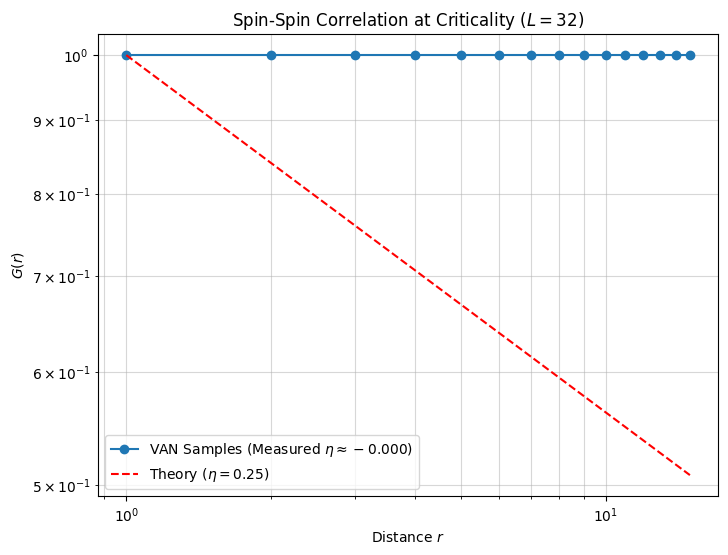

Measured Critical Exponent eta: -0.0000
Theoretical η: 0.2500
Percent Error: 100.00%


In [15]:
from scipy.stats import linregress

# At Tc, G(r) follows a power law: G(r) ~ r^(-eta)
# We take the log of r and G(r) to find the slope
log_r = np.log(rs)
log_gr = np.log(gr)

# Perform linear regression to find the measured eta
slope, intercept, r_value, p_value, std_err = linregress(log_r, log_gr)
eta_measured = -slope

plt.figure(figsize=(8, 6))
# Use double backslashes for LaTeX commands in f-string to prevent Python from misinterpreting escape sequences
plt.loglog(rs, gr, 'o-', label=f'VAN Samples (Measured $\\eta \\approx {eta_measured:.3f}$)')

# Plot the theoretical prediction for comparison (CFT eta=0.25)
# Ensure double backslashes for LaTeX commands
plt.loglog(rs, np.exp(intercept) * rs**(-0.25), '--', color='red', label='Theory ($\eta = 0.25$)'
)

plt.title(f"Spin-Spin Correlation at Criticality ($L=32$)")
plt.xlabel("Distance $r$")
plt.ylabel("$G(r)$")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

print(f"Measured Critical Exponent eta: {eta_measured:.4f}")
print(f"Theoretical η: 0.2500")
print(f"Percent Error: {abs(eta_measured - 0.25)/0.25 * 100:.2f}%")

Unfortunately, the spins are indeed perfectly correlated.

Our network has sampled a zero temperature ordered ground state instead of a critical state.  To encourage it to leave what is hopefully a local but not global minimum in the loss landscape, we turn to *simulated annealing*, which will start the Ising model at a higher than critical temperature and lower the temperature back to criticality.  This requires a modified training procedure:

In [8]:
# --- Setup Parameters ---
L = 32
batch_size = 100 # Further reduced batch size to mitigate OutOfMemoryError
epochs = 1000
learning_rate = 5e-4
#critical temperature and coupling included in definition of Ising class

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model, Ising object, and optimizer
model = IsingPixelCNN().to(device)
ising_phys = IsingModel(L=L, device=device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-5)

def train():
    baseline_F = 0.0
    # Increase momentum to 0.99 for a batch size of 100 to stabilize gradients
    momentum = 0.99

    # Annealing parameters
    T_start = 3.0
    T_target = ising_phys.Tc
    anneal_steps = 400

    pbar = tqdm(range(epochs), desc="VAN Training")

    for epoch in pbar:
        # --- A. SAMPLING PHASE ---
        # Compute the current temperature
        fraction = min(epoch / anneal_steps, 1.0)
        current_T = T_start + (T_target - T_start) * fraction
        # Set to eval to ensure sampling is consistent and memory-efficient
        model.eval()
        with torch.no_grad():
            samples, log_p_orig = sample_van(model, batch_size, L, device)

        # --- B. GRADIENT PHASE ---
        # Switch back to train so we can compute gradients for the update
        model.train()

        # We need to re-calculate log-probs for the augmented batch to keep gradients alive
        s_flip = 1 - samples
        s_ref  = torch.flip(samples, dims=[3])
        s_both = 1 - s_ref

        # Process all 4 sectors (including original) to get symmetrized log_q
        # We include samples here to get a fresh log_p_orig with grad attached
        aug_batch = torch.cat([samples, s_flip, s_ref, s_both], dim=0)
        probs_aug = model(aug_batch)

        # Calculate ln q(s) for all sectors
        log_p_0    = calculate_log_prob(probs_aug[0:batch_size], samples)
        log_p_flip = calculate_log_prob(probs_aug[batch_size:2*batch_size], s_flip)
        log_p_ref  = calculate_log_prob(probs_aug[2*batch_size:3*batch_size], s_ref)
        log_p_both = calculate_log_prob(probs_aug[3*batch_size:], s_both)

        #get entropy
        entropy = -(probs_aug * torch.log(probs_aug + 1e-9) + (1 - probs_aug) * torch.log(1 - probs_aug + 1e-9)).mean()

        # Symmetrized Log-Probability (This tensor has grad_fn attached)
        log_p_avg = (log_p_0 + log_p_flip + log_p_ref + log_p_both) / 4.0

        # --- C. PHYSICS CALCULATION ---
        with torch.no_grad():
            # Convert binary 0/1 to spins -1/1
            spins = 2 * samples - 1
            energies = ising_phys.energy(spins).flatten()

            # Local Free Energy calculation (Reward Signal)
            F_local = energies + current_T * log_p_avg.detach()
            F_mean = F_local.mean()

            # Update baseline (The 'flywheel' for REINFORCE)
            if epoch == 0:
                baseline_F = F_mean
            else:
                baseline_F = momentum * baseline_F + (1 - momentum) * F_mean

        # --- D. LOSS & BACKPROP ---
        # REINFORCE loss: (Reward - Baseline) * log_prob
        lambda_entropy = 0.005
        loss = ((F_local - baseline_F) * log_p_avg).mean() - lambda_entropy * entropy

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Monitoring
        f_density = F_mean / (L*L)
        pbar.set_postfix({"f": f"{f_density.item():.4f}", "base_F": f"{baseline_F.item():.2f}"})

if __name__ == "__main__":
  train()

VAN Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Our most fundamental addition to the training loop is a calculation of the current temperature.  We start will above the critical temperature and decrease linearly until we reach the critical temperature after a set number of epochs.  The initial attempt at an annealed simulation yielded junk.  To attempt to prevent this, we added some weight decay to the optimizer and an entropy term to the loss.  Let's see the results.  As usual, we start by sampling.

In [9]:
# Switch model to evaluation mode
model.eval()

# Generate a large batch of samples for statistics
num_samples = 10000
with torch.no_grad():
    # Using sequential sampling function
    samples, log_probs = sample_van(model, num_samples, L=32, device=device)

    # Map binary {0, 1} to Ising spins {-1, 1}
    spins = 2 * samples - 1

print(f"Generated {num_samples} configurations at Tc.")

Generated 10000 configurations at Tc.


We test the same observables as before.

In [10]:
ising = IsingModel(L=32, device=device)

with torch.no_grad():
    avg_e = ising.energy_density(spins).mean().item()
    avg_m = ising.magnetization(spins).mean().item()
    susc = ising.susceptibility(spins).item()
    c_v = ising.specific_heat(spins).item()

print(f"--- Scalar Observables ---")
print(f"Energy Density: {avg_e:.5f} (Exact Tc: -1.414)")
print(f"Magnetization <|m|>: {avg_m:.5f}")
print(f"Susceptibility: {susc:.5f}")
print(f"Specific Heat: {c_v:.5f}")

--- Scalar Observables ---
Energy Density: -1.00592 (Exact Tc: -1.414)
Magnetization <|m|>: 0.12671
Susceptibility: 3.81288
Specific Heat: 1.11258


These are more encouraging.  The magnetization is much smaller than it was, even though it is not vanishing.  The energy is higher than its known value, indicating that we are some distance from criticality.  The sizeable specific heat and susceptibility are promising.  Let's look at the two point function.

In [11]:
def calculate_full_corr(lattices, L):
    """
    Calculates G(r) = <S_i S_{i+r}> averaged over all i and all directions.
    r ranges from 1 to L/2 (due to PBC and minimum image convention).
    """
    rs = np.arange(1, L // 2)
    gr = []

    for r in rs:
        # Average correlations in x and y directions to increase signal-to-noise
        corr_x = (lattices * torch.roll(lattices, shifts=-r, dims=3)).mean()
        corr_y = (lattices * torch.roll(lattices, shifts=-r, dims=2)).mean()
        gr.append(((corr_x + corr_y) / 2).item())

    return rs, np.array(gr)

rs, gr = calculate_full_corr(spins, L=32)

print("Distance r:", rs)
print("G(r):", gr)

Distance r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
G(r): [0.5029611  0.31724805 0.21256289 0.14871347 0.10744687 0.08001718
 0.0624373  0.04970586 0.04112187 0.03572285 0.03259238 0.0306164
 0.02958242 0.02936777 0.0292666 ]


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_12436/426407417.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.loglog(rs, np.exp(intercept) * rs**(-0.25), '--', color='red', label='Theory ($\eta = 0.25$)'


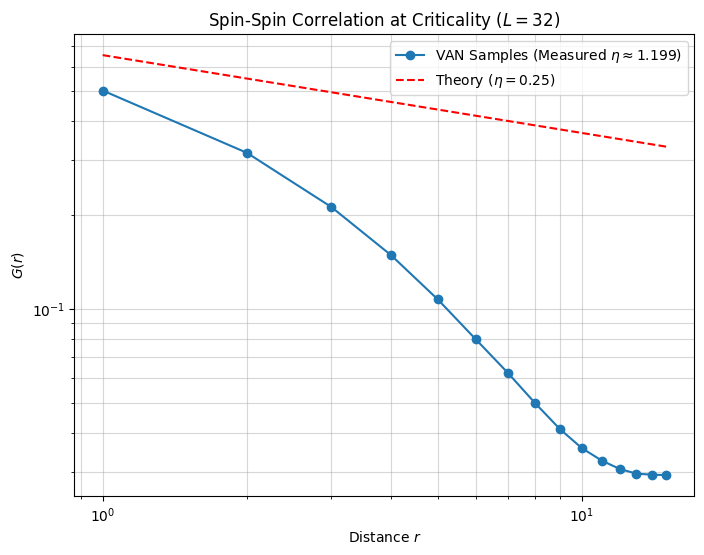

Measured Critical Exponent eta: 1.1989
Theoretical η: 0.2500
Percent Error: 379.58%


In [12]:
from scipy.stats import linregress

# At Tc, G(r) follows a power law: G(r) ~ r^(-eta)
# We take the log of r and G(r) to find the slope
log_r = np.log(rs)
log_gr = np.log(gr)

# Perform linear regression to find the measured eta
slope, intercept, r_value, p_value, std_err = linregress(log_r, log_gr)
eta_measured = -slope

plt.figure(figsize=(8, 6))
# Use double backslashes for LaTeX commands in f-string to prevent Python from misinterpreting escape sequences
plt.loglog(rs, gr, 'o-', label=f'VAN Samples (Measured $\\eta \\approx {eta_measured:.3f}$)')

# Plot the theoretical prediction for comparison (CFT eta=0.25)
# Ensure double backslashes for LaTeX commands
plt.loglog(rs, np.exp(intercept) * rs**(-0.25), '--', color='red', label='Theory ($\eta = 0.25$)'
)

plt.title(f"Spin-Spin Correlation at Criticality ($L=32$)")
plt.xlabel("Distance $r$")
plt.ylabel("$G(r)$")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

print(f"Measured Critical Exponent eta: {eta_measured:.4f}")
print(f"Theoretical η: 0.2500")
print(f"Percent Error: {abs(eta_measured - 0.25)/0.25 * 100:.2f}%")

This is improvement - the function now actually decays, but not in the power law way that we expect at criticality.  To get a final idea of the physics before quoting a metric, we print some samples.

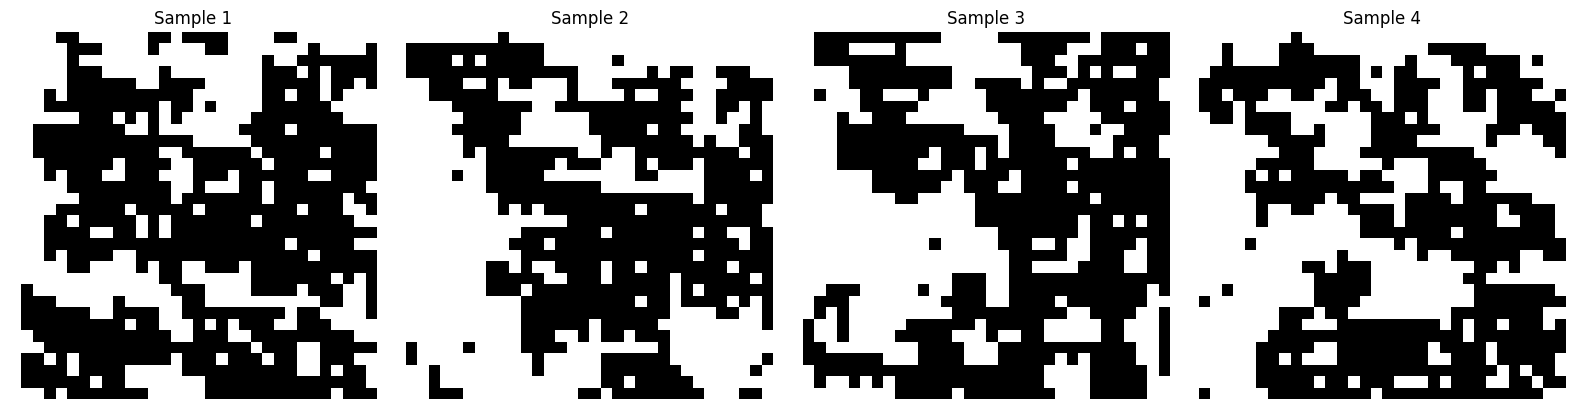

In [13]:
def plot_samples(model, batch_size=4, L=32, device='cuda'):
    model.eval()
    # Generate fresh samples using your sampling function
    with torch.no_grad():
        samples, _ = sample_van(model, batch_size, L, device)

    # Convert to numpy for plotting (batch, 1, 32, 32)
    samples_np = samples.cpu().numpy()

    fig, axes = plt.subplots(1, batch_size, figsize=(batch_size * 4, 4))
    if batch_size == 1:
        axes = [axes]

    for i in range(batch_size):
        # We plot the configuration (0s and 1s)
        axes[i].imshow(samples_np[i, 0], cmap='binary', interpolation='nearest')
        axes[i].set_title(f"Sample {i+1}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run it!
plot_samples(model, batch_size=4, L=L, device=device)

These show some signals of criticality.  There is domain formation and some white domains strich almost the entire length of the lattice.  Some domains are also quite small, consistent with the expected lack of characteristic length scale at criticality.  We now give a metric.  Following 1809.10606, we evaluate the model using the reverse KL divergence:

In [15]:
def compute_reverse_kl(model, ising_phys, batch_size=1024, L=32, device='cuda'):
    """
    Computes the Reverse KL Divergence: KL(q_theta || p)
    KL = <ln q_theta(s)> - <ln p(s)>
    where ln p(s) = -beta * E(s) - ln Z
    """
    model.eval()
    beta = 1.0 / ising_phys.Tc

    with torch.no_grad():
        # 1. Sample from the model (q_theta)
        samples, log_q = sample_van(model, batch_size, L, device)

        # 2. Calculate Energy of these samples
        spins = 2 * samples - 1
        energies = ising_phys.energy(spins).flatten()

        # 3. Exact log Z for 2D Ising (Onsager's Solution)
        # For L=32, we use the known free energy density f_exact approx -2.45
        f_exact = -2.4516 # Exact value for 2D Ising at Tc
        ln_Z = -beta * (f_exact * L * L)

        # 4. Compute ln p(s) = -beta * E(s) - ln Z
        log_p = -beta * energies - ln_Z

        # 5. KL = Mean(log_q - log_p)
        kl_div = (log_q - log_p).mean()

        return kl_div.item()

# Usage
kl_value = compute_reverse_kl(model, ising_phys, batch_size=2000, L=L, device=device)
print(f"Reverse KL Divergence: {kl_value:.4f}")

Reverse KL Divergence: 210.5996


Clearly, we are not quite at criticality.  This could have been anticipated by the higher energy, slight imbalance in fabor of black in the plotted samples, and the lack of power law decay of the point function.  However, as we iterated the algorithm, the sample looked more critical.  Given more time and compute, we imagin we could deform hyperparameters until a critical sample is achieved.